In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Introducción y carga de datos

Este dataset contiene información sobre reservas de hoteles hechas a lo largo del tiempo, incluyendo detalles sobre los clientes, el comportamiento de reserva y la probabilidad de cancelación.
- El objetivo es predecir si una reserva será cancelada (`is_canceled = 1`) o no (`is_canceled = 0`).
## Variables

| Nombre Variable                  | Descripción                                              |
| -------------------------------- | -------------------------------------------------------- |
| `hotel`                          | Tipo de hotel: City Hotel o Resort Hotel                 |
| `is_canceled`                    | Variable objetivo: 1 si fue cancelado, 0 si no           |
| `lead_time`                      | Días entre la reserva y la fecha de llegada              |
| `arrival_date_year`              | Año de llegada                                           |
| `arrival_date_month`             | Mes de llegada                                           |
| `arrival_date_week_number`       | Número de la semana del año                              |
| `arrival_date_day_of_month`      | Día del mes de llegada                                   |
| `stays_in_weekend_nights`        | Noches de fin de semana reservadas                       |
| `stays_in_week_nights`           | Noches entre semana reservadas                           |
| `adults`                         | Número de adultos                                        |
| `children`                       | Número de niños                                          |
| `babies`                         | Número de bebés                                          |
| `meal`                           | Tipo de comida reservada                                 |
| `country`                        | País de origen del cliente                               |
| `market_segment`                 | Canal de marketing (online, offline, grupos...)          |
| `distribution_channel`           | Canal de distribución (directo, TA/TO...)                |
| `is_repeated_guest`              | 1 si el cliente ha estado anteriormente                  |
| `previous_cancellations`         | Nº de cancelaciones anteriores                           |
| `previous_bookings_not_canceled` | Nº de reservas previas no canceladas                     |
| `reserved_room_type`             | Tipo de habitación reservada                             |
| `assigned_room_type`             | Tipo de habitación asignada                              |
| `booking_changes`                | Nº de cambios en la reserva                              |
| `deposit_type`                   | Tipo de depósito: No Deposit, Refundable, etc.           |
| `agent`                          | ID del agente (puede ser nulo)                           |
| `company`                        | ID de la empresa (puede ser nulo)                        |
| `days_in_waiting_list`           | Días en lista de espera                                  |
| `customer_type`                  | Tipo de cliente: Transient, Group, etc.                  |
| `adr`                            | Average Daily Rate (precio promedio por noche)           |
| `required_car_parking_spaces`    | Plazas de parking solicitadas                            |
| `total_of_special_requests`      | Nº de peticiones especiales                              |
| `reservation_status`             | Estado final de la reserva: Check-Out, Canceled, No-Show |
| `reservation_status_date`        | Fecha en que se actualizó el estado                      |

In [3]:
df = pd.read_csv('../data/dataset_practica_final.csv')
print(f"Dimensiones del dataset: {df.shape}")
df.head()

Dimensiones del dataset: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
# Información del dataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [167]:
df.dtypes

hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent                             

In [168]:
# Descripción estadistica de las columnas numericas
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


## 2. Analisis de la Variable Objetivo (is_canceled)

In [169]:
print("Recuento absoluto:")
print(df['is_canceled'].value_counts())

print("\nPorcentaje (%):")
print((df['is_canceled'].value_counts(normalize=True) * 100).round(2))

Recuento absoluto:
is_canceled
0    75166
1    44224
Name: count, dtype: int64

Porcentaje (%):
is_canceled
0    62.96
1    37.04
Name: proportion, dtype: float64


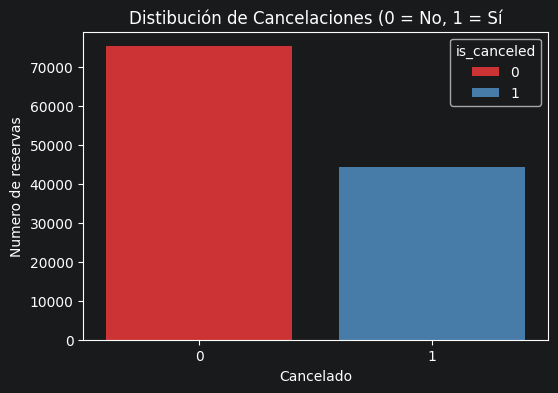

In [170]:
# Visualización de cancelaciones
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='is_canceled', palette='Set1', hue='is_canceled')
plt.title('Distibución de Cancelaciones (0 = No, 1 = Sí')
plt.xlabel('Cancelado')
plt.ylabel('Numero de reservas')
plt.show()


El **63%** de las reservas no se cancelan (0), el **37%** si se cancelan (1)

# 3. Calidad de Datos, Nulos y Undefined

## 3.1. Detección de Nulos

In [171]:
# Valores nulos
df.isna().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

Tratamiento que haremos con los nulos
- children (4) -> Convertir a 0
- country (488) -> Convertir al pais mas común
- agent (16340) -> Sino viene por agencia será un particular, le asignaremos un 0
- company (112593) -> Convertirla a binario has_company: 1 o has_company: 0

## 3.2. Detección de "Undefined"

Columnas categóricas con valores "Undefined"

- meal (1169): lo sustituiremos por la BB
- market_segment (2): lo sustituiremos por Online TA
- distribution_channel: lo sutituiremos por TA/TO

## 3.3 Análisis de paises

In [172]:
# Miramos los 10 países con más reservas y su porcentaje sobre el total
total_paises = df['country'].value_counts().count()
print(total_paises)
top_paises = df['country'].value_counts().head(10)
top_paises_pct = (top_paises / len(df)) * 100
pd.DataFrame({'Reservas': top_paises, 'Porcentaje (%)':
top_paises_pct.round(2)})

177


,Reservas,Porcentaje (%)
country,,
PRT,48590,40.70
GBR,12129,10.16
FRA,10415,8.72
ESP,8568,7.18
DEU,7287,6.10
ITA,3766,3.15
IRL,3375,2.83
BEL,2342,1.96
BRA,2224,1.86


In [173]:
low_paises = df['country'].value_counts().tail(10)
low_paises_pct = (low_paises / len(df)) * 100
pd.DataFrame({'Reservas': low_paises, 'Porcentaje (%)': low_paises_pct.round(2)})

,Reservas,Porcentaje (%)
country,,
MMR,1,0.0
NPL,1,0.0
BHS,1,0.0
UMI,1,0.0
SMR,1,0.0
DJI,1,0.0
BWA,1,0.0
HND,1,0.0
VGB,1,0.0


In [174]:
conteo = df['country'].value_counts()
print(f"Total de países distintos: {df['country'].nunique()}")
print(f"Países con menos de 10 reservas: {(conteo < 10).sum()}")
print(f"Porcentaje que representa el Top 5: {(conteo.head(5).sum() / len(df) * 100).round(1)}%")

Total de países distintos: 177
Países con menos de 10 reservas: 81
Porcentaje que representa el Top 5: 72.9%


De 177 paises 5 suponen casi el 75% de las reservas.
- Nos quedaremos con los 5 primeros y el resto los agruparemos en Others

# 4. Datos a descartar
- reservation_status y reservation_status_date son datos conocidos a posteriori... estarían contaminando el entrenamiento, los eliminaremos del dataset.

# 5. Análisis de las relaciones con la Cancelación

## 5.1 Variables numéricas

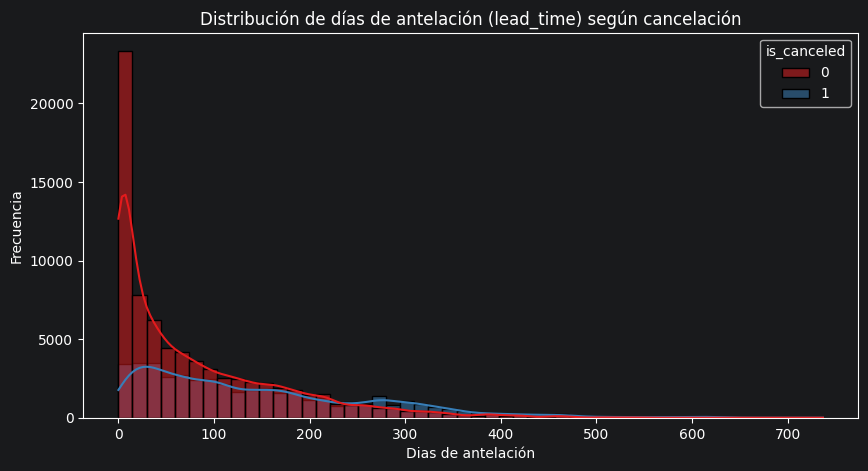

In [175]:
# Visualizamos relacion entre cancelaciones y dias de antelación de las reservas
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='lead_time', hue='is_canceled', kde=True, palette='Set1', bins=50)
plt.title('Distribución de días de antelación (lead_time) según cancelación')
plt.xlabel('Dias de antelación')
plt.ylabel('Frecuencia')
plt.show()

#### La relación entre cancelacion y lead_time, nos muestra que cuando reservan con mucha antelación la probabilidad de cancelar aumenta. Y por encima de 250 dias son mas las Cancelaciones que las No-Cancelaciones

Valores mínimos de ADR:
14969   -6.38
0        0.00
1        0.00
Name: adr, dtype: float64

Valores máximos de ADR:
48515     5400.0
111403     510.0
15083      508.0
Name: adr, dtype: float64


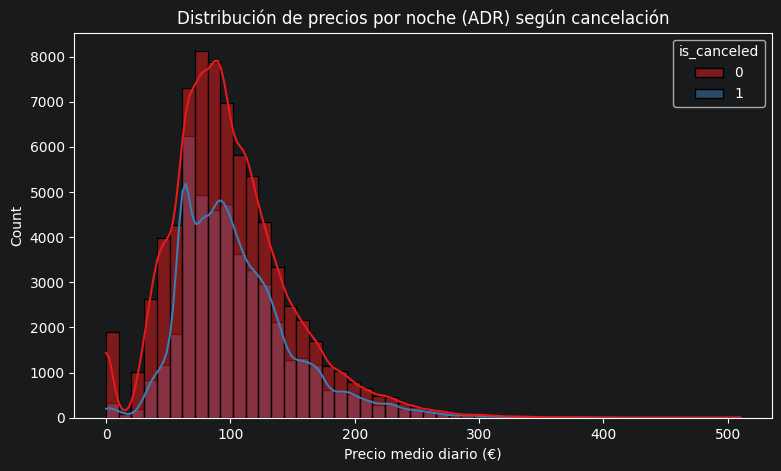

In [184]:
# Relación entre cancelaciones y precio por noche
## Nota detectamos un valor negativo y un valor exageradamente grande de 5400... los filtramos para no desvirtuar la grafica
print("Valores mínimos de ADR:")
print(df['adr'].nsmallest(3))

print("\nValores máximos de ADR:")
print(df['adr'].nlargest(3))
plt.figure(figsize=(9,5))
sns.histplot(data=df[(df['adr'] >= 0) & (df['adr'] < 1000)], x='adr', hue='is_canceled', kde=True, palette='Set1', bins=50)
plt.title('Distribución de precios por noche (ADR) según cancelación')
plt.xlabel('Precio medio diario (€)')
plt.show()

#### Las curvas son similares, no parece haber una relación entre precio noche y cancelación.

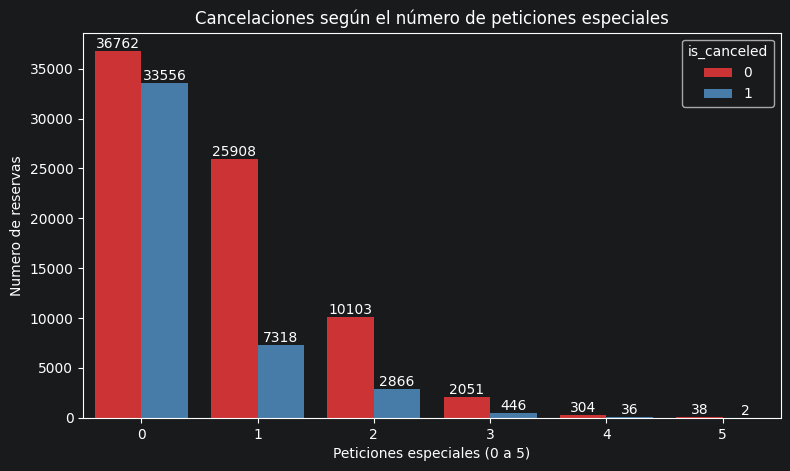

In [177]:
# Visualizamos conteo de cancelaciones según la cantidad de peticiones especiales
plt.figure(figsize=(9,5))
ax = sns.countplot(data=df, x='total_of_special_requests', hue='is_canceled', palette='Set1')
plt.title('Cancelaciones según el número de peticiones especiales')
plt.xlabel('Peticiones especiales (0 a 5)')
plt.ylabel('Numero de reservas')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

#### Se aprecia que cuando el cliente hace peticiones especiales es mas probable que no cancele

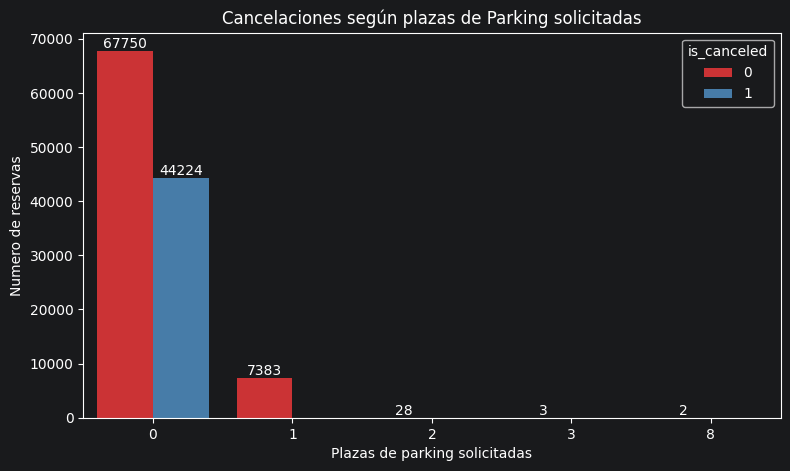

In [178]:
# Visualizamos conteo de cancelaciones según la petición de plaza de parking
plt.figure(figsize=(9,5))
ax = sns.countplot(data=df, x='required_car_parking_spaces', hue='is_canceled', palette='Set1')
plt.title('Cancelaciones según plazas de Parking solicitadas')
plt.xlabel('Plazas de parking solicitadas')
plt.ylabel('Numero de reservas')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

#### Cuando se solicita parking las cancelaciones son inexistentes

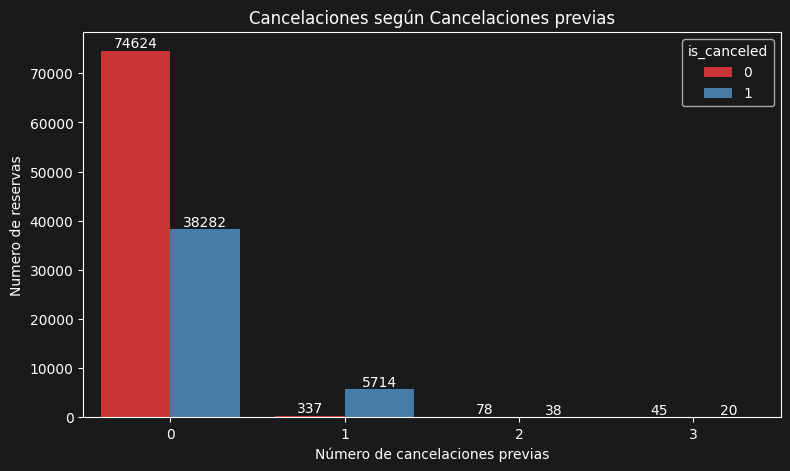

In [179]:
# Visualizamos conteo de cancelaciones según las cancelaciones previas, lo limitamos a 3 para mejor visualización
plt.figure(figsize=(9,5))
ax = sns.countplot(data=df[df['previous_cancellations'] <=3], x='previous_cancellations', hue='is_canceled', palette='Set1')
plt.title('Cancelaciones según Cancelaciones previas')
plt.xlabel('Número de cancelaciones previas')
plt.ylabel('Numero de reservas')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

#### Los que ya cancelaron antes tienen altas probabilidades de volver a cancelar

## 5.2 Variables catégoricas

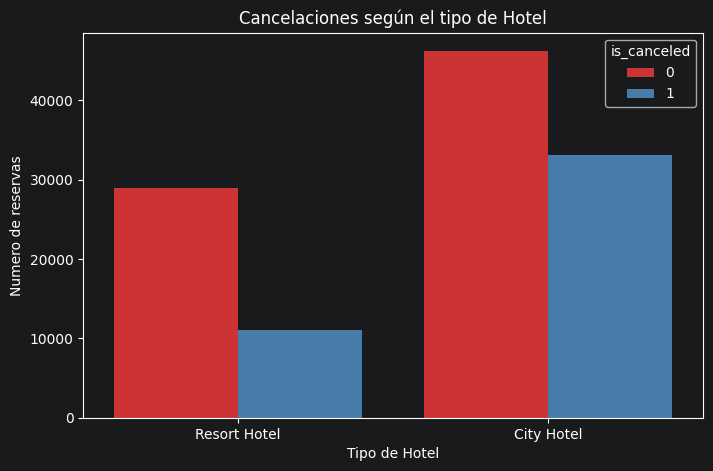

In [180]:
# Visualizamos conteo de cancelaciones según el tipo de hotel
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='hotel', hue='is_canceled', palette='Set1')
plt.title('Cancelaciones según el tipo de Hotel')
plt.xlabel('Tipo de Hotel')
plt.ylabel('Numero de reservas')
plt.show()

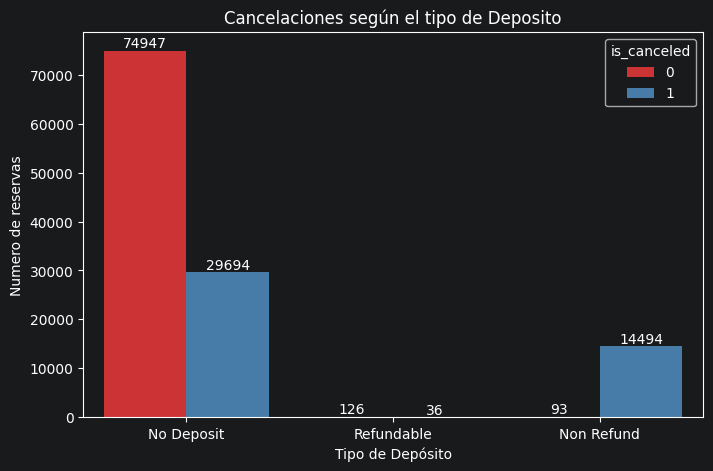

In [181]:
# Visualizamos conteo de cancelaciones según el tipo de depósito
plt.figure(figsize=(8,5))
ax = sns.countplot(data=df, x='deposit_type', hue='is_canceled', palette='Set1')
plt.title('Cancelaciones según el tipo de Deposito')
plt.xlabel('Tipo de Depósito')
plt.ylabel('Numero de reservas')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

#### Los depositos Refundable son minoritarios en el dataset. Cuando el deposito no es re-embolsable el numero de cancelaciones es cercano al 100%... Contra-intuitivo!!

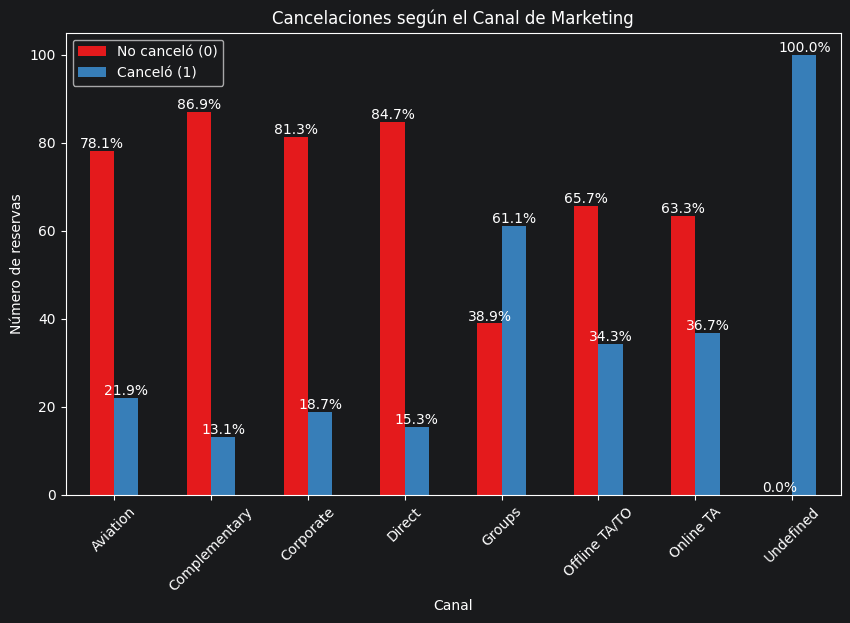

In [182]:

# Conteo de cancelaciones segun el canal de marketing
pct = pd.crosstab(df['market_segment'], df['is_canceled'], normalize='index') * 100
ax = pct.plot(kind='bar', figsize=(10, 6), color=['#e41a1c',
  '#377eb8'])

plt.title('Cancelaciones según el Canal de Marketing')
plt.xlabel('Canal')
plt.ylabel('Número de reservas')
plt.xticks(rotation=45)
plt.legend(['No canceló (0)', 'Canceló (1)'])

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.show()


#### Los clientes mas fieles son los que compran Directo, Corporativos o Complementary, mientras que los Grupos tiene cancelan 2 de cada 3 reservas!!

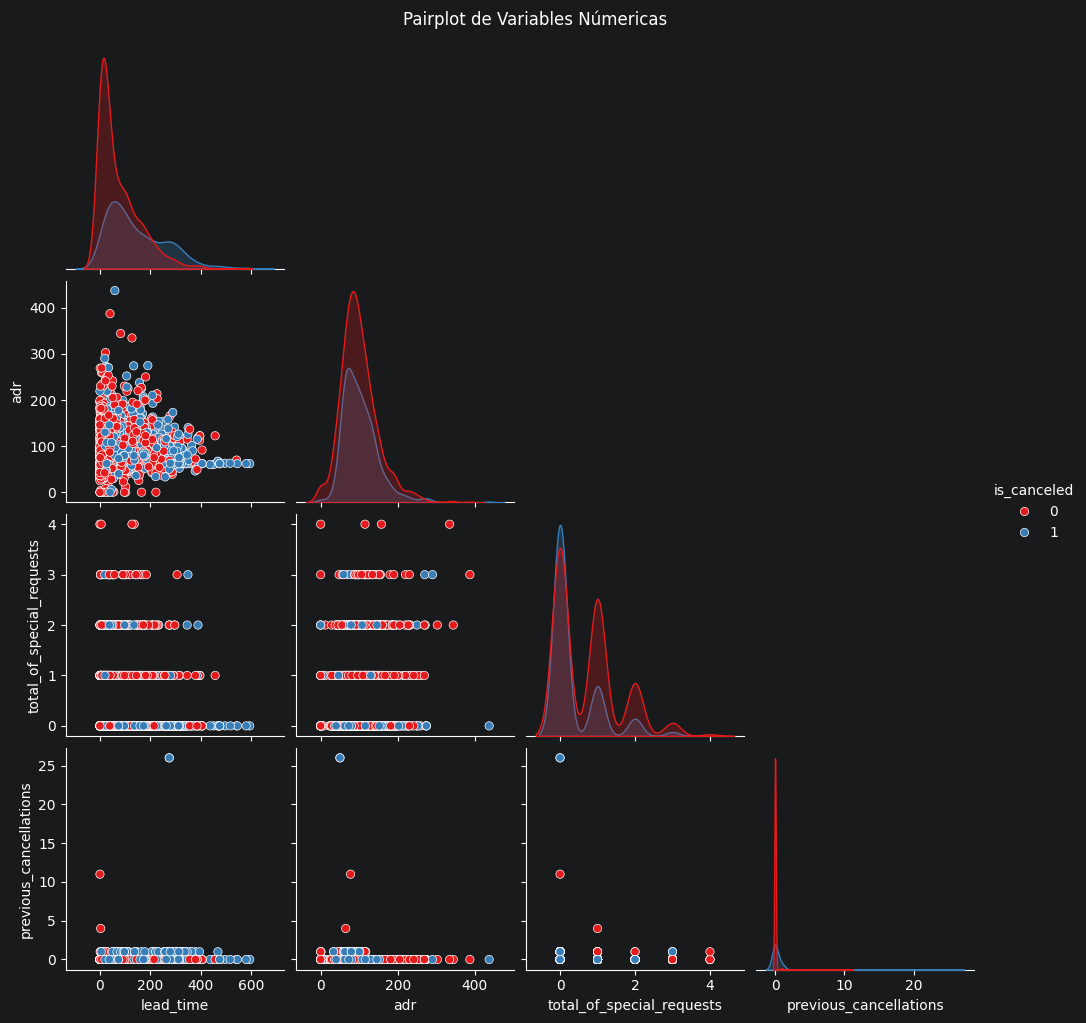

In [183]:
columnas_pairplot = ['lead_time', 'adr', 'total_of_special_requests', 'previous_cancellations', 'is_canceled']
df_muestra = df[(df['adr'] >= 0) & (df['adr'] < 1000)][columnas_pairplot].sample(1500, random_state=42)
sns.pairplot(df_muestra, hue='is_canceled', palette='Set1', corner=True)
plt.suptitle('Pairplot de Variables Númericas ', y=1.02)
plt.show()